# Análisi de Fourier
## Senos y Cosenos en 2D

In [ ]:
%pip install ipywidgets

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import widget
from IPython.display import display


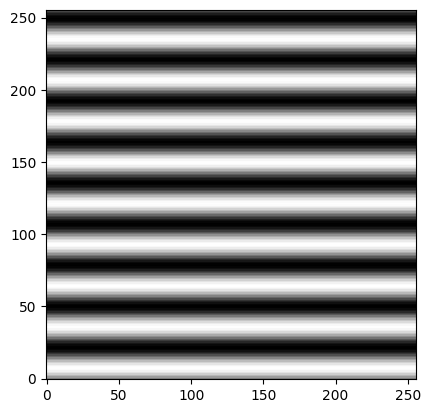

In [21]:
def sine2D(N, M, n, m, u, v, A=1):
    return A * np.sin(2*np.pi*((u*n/N) + (v*m/M)))
def cosine2D(N, M, n, m, u, v, A=1):
    return A * np.cos(2*np.pi*((u*n/N) + (v*m/M)))

def apply_func(func, matrix, u, v):
    N,M = matrix.shape
    mat_aux = np.zeros_like(matrix)
    for n in range(N):
        for m in range(M):
            mat_aux[n,m] = func(N, M, n, m, u, v)
    return (255.0 * ((mat_aux + 1) / 2)).astype(np.uint8)

N,M = (256,256)
matrix = np.zeros((N,M))
matrix_sin = apply_func(sine2D, matrix, 9, 0)

plt.imshow(matrix_sin, cmap="gray", interpolation="nearest", origin="lower")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def generate_func(frecuencia_horizontal=0, frecuencia_vertical=0, func=0):
    N,M = (20,20)
    matrix = np.zeros((N,M))
    f = sine2D if func == 0 else cosine2D
    matrix_sin = apply_func(f, matrix, frecuencia_horizontal, frecuencia_vertical)
    plt.imshow(matrix_sin, cmap="gray", interpolation="nearest", origin="lower")
    plt.show()

widgets_interact = widgets.interactive(
    generate_func,
    frecuencia_horizontal=widgets.FloatSlider(min=0,max=20,step=0.1,value=0),
    frecuencia_vertical=widgets.FloatSlider(min=0,max=20,step=0.1,value=0),
    func=widgets.ToggleButtons(
        options=[('Seno',0),('Coseno',1)]
    )
)

display(widgets_interact)

interactive(children=(FloatSlider(value=0.0, description='frecuencia_horizontal', max=20.0), FloatSlider(value…

## Transformada de Fourier 2D

In [30]:
def get_fft(image, log=True):
    fft = np.fft.fft2(image)
    fft_shifted = np.fft.fftshift(fft) # Se mueve la frecuencia 0 (DC) al centro de la imagen
    #fft_spectrum = 20*np.log(np.abs(fft_shifted)) # Espectro - Módulo en escala logarítmica
    if log: 
        return np.log(np.abs(fft_shifted) + 1)
    return np.abs(fft_shifted)

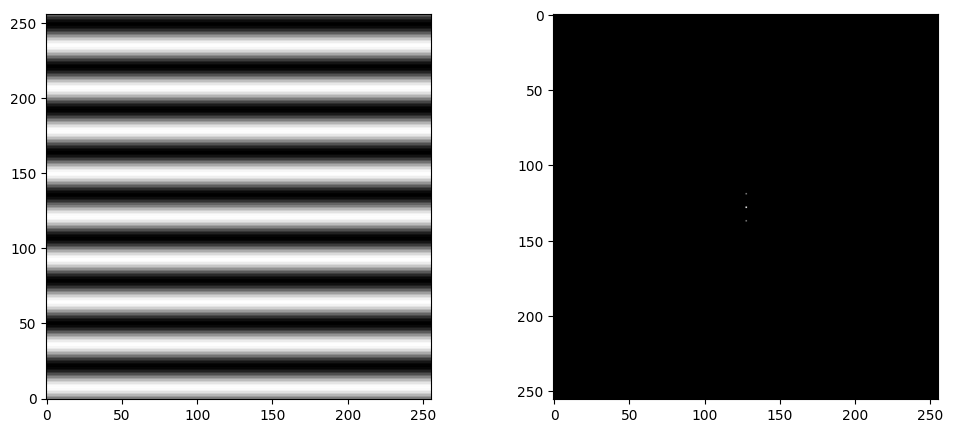

In [31]:
fft_image = get_fft(matrix_sin, False)

fig, axs = plt.subplots(1, 2, figsize=(12,5))
axs[0].imshow(matrix_sin, cmap="gray", interpolation="nearest", origin="lower")
axs[1].imshow(fft_image, cmap="gray")
plt.show()

In [35]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def generate_func(frecuencia_horizontal=0, frecuencia_vertical=0, func=0):
    N,M = (256,256)
    matrix = np.zeros((N,M))
    f = sine2D if func == 0 else cosine2D
    matrix_sin = apply_func(f, matrix, frecuencia_horizontal, frecuencia_vertical)
    fft_image = get_fft(matrix_sin, False)

    fig, axs = plt.subplots(1, 2, figsize=(12,5))
    axs[0].imshow(matrix_sin, cmap="gray", interpolation="nearest", origin="lower")
    axs[1].imshow(fft_image, cmap="gray")
    plt.show()

widgets_interact = widgets.interactive(
    generate_func,
    frecuencia_horizontal=widgets.FloatSlider(min=-30,max=30,step=0.1,value=0),
    frecuencia_vertical=widgets.FloatSlider(min=-30,max=30,step=0.1,value=0),
    func=widgets.ToggleButtons(
        options=[('Seno',0),('Coseno',1)]
    )
)

display(widgets_interact)
# Cudrículas por alisiang - El número de pixeles debe cumplir con el teorema de Nyquist.

interactive(children=(FloatSlider(value=0.0, description='frecuencia_horizontal', max=30.0, min=-30.0), FloatS…

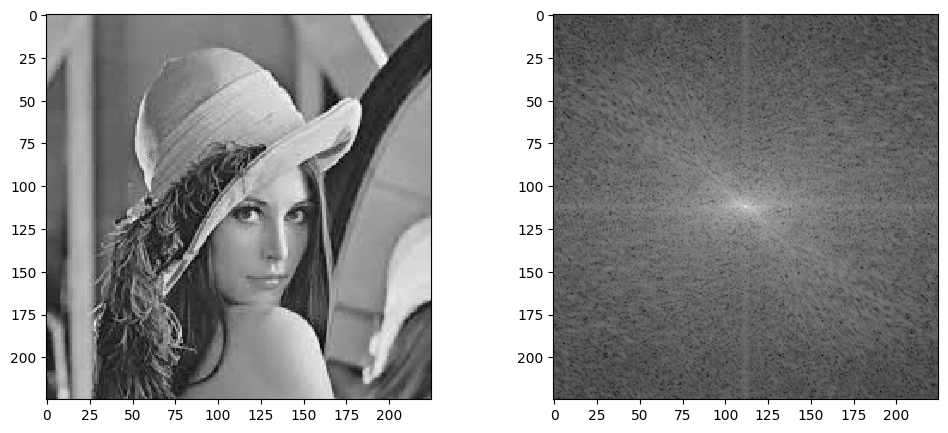

In [40]:
img = cv2.imread("img/lena.jpeg", cv2.IMREAD_GRAYSCALE)
fft_image = get_fft(img, True)
fig, axs = plt.subplots(1, 2, figsize=(12,5))
axs[0].imshow(img, cmap="gray", interpolation="nearest")
axs[1].imshow(fft_image, cmap="gray")
plt.show()